In [1]:
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
k_list = [5,16 ,32 ,64 ,80 ,96 ,128 ,160 ,200 ,240 ,280 ,320 ,340 ,400]
import re
from scipy import stats
import numpy as np
def extract_scores(text):
    # Extracting the required scores from the text with a very flexible comet score pattern
    results = {}

    # Splitting the text based on the dynamic path pattern
    path_pattern = r'/raid/lyu/.*?score:'
    split_text = re.split(path_pattern, text)
    if len(split_text) < 2:
        return "No valid path or score data found in the text."

    json_data_part = split_text[0].strip()
    scores_part = 'score:' + split_text[1].strip()

    # Extracting JSON data for BLEU and chrF2
    try:
        json_data = eval(json_data_part)
        for data in json_data:
            if data["name"] in ["BLEU", "chrF2"]:
                results[data["name"]] = data["score"]
    except:
        return "Error in parsing JSON data."

    # Extracting scores from the scores part with a very flexible pattern for comet score
    comet_score = re.search(r'score:\s*([0-9.]+)', scores_part)
    entity_accuracy = re.search(r'Total Accuracy:\s*([0-9.]+)', scores_part)
    bertscore_f1 = re.search(r'bert.*F1:\s*([0-9.]+)', scores_part)
    bleurt_score = re.search(r'([0-9.]+)\s*$', scores_part)

    if comet_score:
        results["comet"] = float(comet_score.group(1))
    if entity_accuracy:
        results["entity Accuracy"] = float(entity_accuracy.group(1))
    if bertscore_f1:
        results["bertscore F1"] = float(bertscore_f1.group(1))
    if bleurt_score:
        results["BLEURT"] = float(bleurt_score.group(1))

    return results


In [2]:
#en-de high resource
path_prefix="/raid/lyu/QEBT/test_dev/test_en2de_low/sMBR"
ref_file="/raid/lyu/QEBT/en2de/wmt2020.de.filter"

In [3]:
#read data
bs_model_score = {}
bs_mbr_score = {}
bs_qe_score = {}
bs_smbr_score = {}
for k in tqdm(k_list):
    with open(path_prefix+'_bs/output_{}/baseline/ct2_output.hypo_{}.score'.format(k,k),"r",encoding="utf-8") as f:
        bs_model_score[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'_bs/output_{}/mbr_baseline/mbr.score'.format(k),"r",encoding="utf-8") as f:
        tmp_list = [json.loads(line.strip()) for line in f.readlines()]
        #reshape
        bs_mbr_score[k] = []
        for i in range(len(tmp_list)):
            bs_mbr_score[k].extend(tmp_list[i])
    with open(path_prefix+'_bs/output_{}/qe_baseline/qe.output.score'.format(k),"r",encoding="utf-8") as f:
        bs_qe_score[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'_bs/output_{}/sMBR.output.score'.format(k),"r",encoding="utf-8") as f:
        bs_smbr_score[k] = [float(line.strip()) for line in f.readlines()]
    assert len(bs_model_score[k]) == len(bs_mbr_score[k]) == len(bs_qe_score[k])== len(bs_smbr_score[k])

100%|██████████| 14/14 [00:11<00:00,  1.19it/s]


In [4]:
bs_pearsonr_mbr_modelscore = []
bs_pearsonr_qe_modelscore = []
bs_pearsonr_qe_mbrs = []
bs_pearsonr_smbr_modelscore = []
bs_pearsonr_smbr_mbr = []
bs_pearsonr_smbr_qe = []
for k in tqdm(k_list,desc="calculating pearsonr",total=len(k_list)):
    bs_pearsonr_mbr_modelscore.append(stats.pearsonr(bs_mbr_score[k],bs_model_score[k])[0])
    bs_pearsonr_qe_modelscore.append(stats.pearsonr(bs_qe_score[k],bs_model_score[k])[0])
    bs_pearsonr_qe_mbrs.append(stats.pearsonr(bs_qe_score[k],bs_mbr_score[k])[0])
    bs_pearsonr_smbr_modelscore.append(stats.pearsonr(bs_smbr_score[k],bs_model_score[k])[0])
    bs_pearsonr_smbr_mbr.append(stats.pearsonr(bs_smbr_score[k],bs_mbr_score[k])[0])
    bs_pearsonr_smbr_qe.append(stats.pearsonr(bs_smbr_score[k],bs_qe_score[k])[0])

calculating pearsonr: 100%|██████████| 14/14 [00:02<00:00,  5.49it/s]


In [5]:
from scipy.stats import spearmanr
from scipy.stats import rankdata
from multiprocessing import Pool

# Define your existing data structures
bs_qe_rank = {}
bs_mbr_rank = {}
bs_model_rank = {}
bs_smbr_rank = {}
bs_spearmanr_qe_modelscore = []
bs_spearmanr_mbr_modelscore = []
bs_spearmanr_qe_mbrs = []
bs_spearmanr_smbr_modelscore = []
bs_spearmanr_smbr_mbr = []
bs_spearmanr_smbr_qe = []
    

def process_k_bs(k):
    qe_rank, mbr_rank, model_rank,smbr_rank = [], [], [],[]
    for i in range(len(bs_mbr_score[k]) // k):
        tmp_qe = bs_qe_score[k][i*k:(i+1)*k]
        tmp_mbr = bs_mbr_score[k][i*k:(i+1)*k]
        tmp_model = bs_model_score[k][i*k:(i+1)*k]
        tmp_smbr = bs_smbr_score[k][i*k:(i+1)*k]

        ranked_qe = rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe = [k+1-x for x in ranked_qe]
        ranked_mbr = rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr = [k+1-x for x in ranked_mbr]
        ranked_model = rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model = [k+1-x for x in ranked_model]
        ranked_smbr = rankdata(tmp_smbr, method='dense').astype(int).tolist()
        ranked_smbr = [k+1-x for x in ranked_smbr]

        qe_rank.extend(ranked_qe)
        mbr_rank.extend(ranked_mbr)
        model_rank.extend(ranked_model)
        smbr_rank.extend(ranked_smbr)
        

    return (qe_rank, mbr_rank, model_rank, 
            spearmanr(qe_rank, model_rank)[0], 
            spearmanr(mbr_rank, model_rank)[0], 
            spearmanr(qe_rank, mbr_rank)[0],
            spearmanr(smbr_rank, model_rank)[0],
            spearmanr(smbr_rank, mbr_rank)[0],
            spearmanr(smbr_rank, qe_rank)[0])

# Use multiprocessing to parallelize the loop
if __name__ == "__main__":
    with Pool() as pool:
        results = list(tqdm(pool.imap(process_k_bs, k_list), total=len(k_list)))

    # Unpack results and update the data structures
    for k, (qe_rank, mbr_rank, model_rank, sr_qe_model, sr_mbr_model, sr_qe_mbr, sr_smbr_model, sr_smbr_mbr, sr_smbr_qe) in zip(k_list, results):
        bs_qe_rank[k] = qe_rank
        bs_mbr_rank[k] = mbr_rank
        bs_model_rank[k] = model_rank
        bs_smbr_rank[k] = model_rank
        
        bs_spearmanr_qe_modelscore.append(sr_qe_model)
        bs_spearmanr_mbr_modelscore.append(sr_mbr_model)
        bs_spearmanr_qe_mbrs.append(sr_qe_mbr)
        bs_spearmanr_smbr_modelscore.append(sr_smbr_model)
        bs_spearmanr_smbr_mbr.append(sr_smbr_mbr)
        bs_spearmanr_smbr_qe.append(sr_smbr_qe)
    

100%|██████████| 14/14 [00:02<00:00,  6.47it/s]


In [10]:
#save data to cache
import os
cache_path = path_prefix+"cache/"
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
for decoding in ["bs","as"]:
    for score_type in ["model","mbr","qe"]:
        with open(cache_path+"{}_{}_rank.json".format(decoding,score_type),"w",encoding="utf-8") as f:
            json.dump(eval("{}_{}_rank".format(decoding,score_type)),f)
        print("save {}_{}_rank.json".format(decoding,score_type))
        

save bs_model_rank.json
save bs_mbr_rank.json
save bs_qe_rank.json
save as_model_rank.json
save as_mbr_rank.json
save as_qe_rank.json


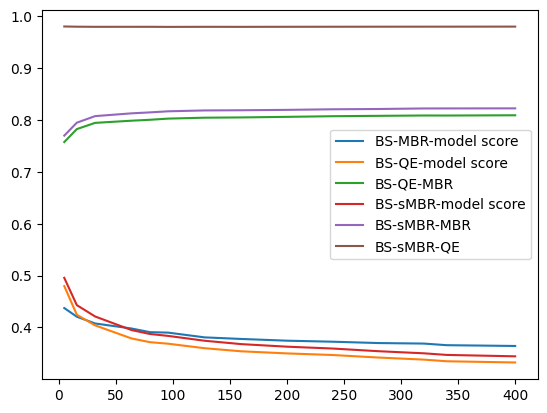

In [6]:
#分别把三个相关系数的折线图画出来
#画在同一张图上，用不同颜色的线表示
#每条线标注名字
plt.figure()
plt.plot(k_list,bs_pearsonr_mbr_modelscore,label="BS-MBR-model score")
plt.plot(k_list,bs_pearsonr_qe_modelscore,label="BS-QE-model score")
plt.plot(k_list,bs_pearsonr_qe_mbrs,label="BS-QE-MBR")
plt.plot(k_list,bs_pearsonr_smbr_modelscore,label="BS-sMBR-model score")
plt.plot(k_list,bs_pearsonr_smbr_mbr,label="BS-sMBR-MBR")
plt.plot(k_list,bs_pearsonr_smbr_qe,label="BS-sMBR-QE")
plt.legend()
plt.show()


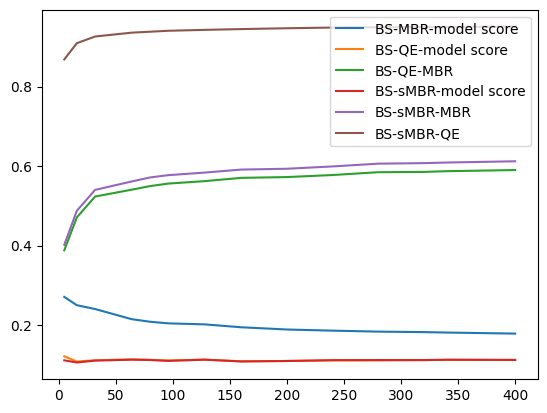

In [7]:
plt.figure()
plt.plot(k_list,bs_spearmanr_mbr_modelscore,label="BS-MBR-model score")
plt.plot(k_list,bs_spearmanr_qe_modelscore,label="BS-QE-model score")
plt.plot(k_list,bs_spearmanr_qe_mbrs,label="BS-QE-MBR")
plt.plot(k_list,bs_spearmanr_smbr_modelscore,label="BS-sMBR-model score")
plt.plot(k_list,bs_spearmanr_smbr_mbr,label="BS-sMBR-MBR")
plt.plot(k_list,bs_spearmanr_smbr_qe,label="BS-sMBR-QE")
plt.legend()
plt.show()

In [8]:
bs_output_text_mbr={}
bs_output_text_qe={}
bs_output_text_bs={}
bs_output_text_smbr={}
for k in tqdm(k_list):
    with open(path_prefix+'_bs/output_{}/mbr_baseline/mbr.output.filter'.format(k,k),"r",encoding="utf-8") as f:
        bs_output_text_mbr[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'_bs/output_{}/qe_baseline/qe.output.filter'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_qe[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'_bs/output_{}/hypo_1'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_bs[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'_bs/output_{}/sMBR.output'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_smbr[k] = [line.strip() for line in f.readlines()]
    assert len(bs_output_text_mbr[k]) == len(bs_output_text_qe[k]) == len(bs_output_text_bs[k]) == len(bs_output_text_smbr[k])


100%|██████████| 14/14 [00:01<00:00,  7.92it/s]


In [9]:
#统计长度分布
bs_mean_len_mbr = []
bs_mean_len_qe = []
bs_mean_len_bs = []
bs_mean_len_smbr = []
bs_std_len_mbr = []
bs_std_len_qe = []
bs_std_len_bs = []
bs_std_len_smbr = []
for k in k_list:
    bs_mean_len_mbr.append(np.mean([len(line) for line in bs_output_text_mbr[k]]))
    bs_mean_len_qe.append(np.mean([len(line) for line in bs_output_text_qe[k]]))
    bs_mean_len_bs.append(np.mean([len(line) for line in bs_output_text_bs[k]]))
    bs_mean_len_smbr.append(np.mean([len(line) for line in bs_output_text_smbr[k]]))
    bs_std_len_mbr.append(np.std([len(line) for line in bs_output_text_mbr[k]]))
    bs_std_len_qe.append(np.std([len(line) for line in bs_output_text_qe[k]]))
    bs_std_len_bs.append(np.std([len(line) for line in bs_output_text_bs[k]]))
    bs_std_len_smbr.append(np.std([len(line) for line in bs_output_text_smbr[k]]))
ref_len=[]   
with open(ref_file,"r",encoding="utf-8") as f:
    ref_text = [line.strip() for line in f.readlines()]
    ref_len=[len(line) for line in ref_text]
ref_mean_len = np.mean([len(line) for line in ref_text])
ref_std_len = np.std([len(line) for line in ref_text])

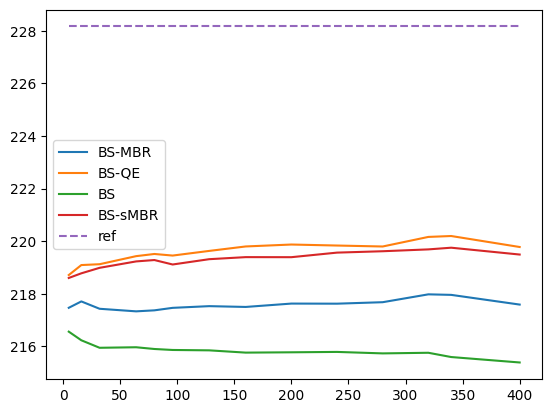

In [14]:
#画出长度分布的折线图
plt.figure()
plt.plot(k_list,bs_mean_len_mbr,label="BS-MBR")
plt.plot(k_list,bs_mean_len_qe,label="BS-QE")
plt.plot(k_list,bs_mean_len_bs,label="BS")
plt.plot(k_list,bs_mean_len_smbr,label="BS-sMBR")
#画一条虚线表示参考译文的长度
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linestyle="--")
plt.legend()
plt.show()

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 407.84it/s]


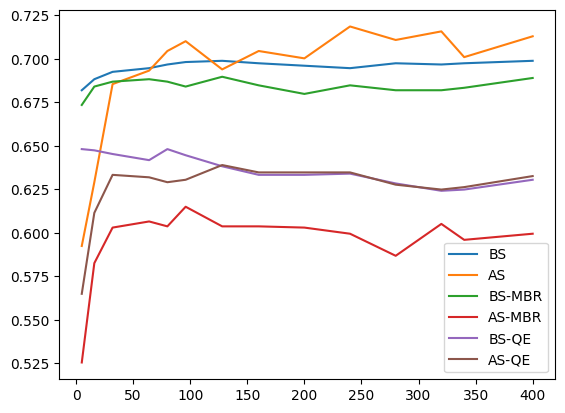

In [40]:
#计算有百分之多少的翻译的长度小于对应的参考译文的长度
bs_less_than_ref = []
bs_mbr_less_than_ref = []
bs_qe_less_than_ref = []
bs_smbr_less_than_ref = []
#先统计一下各种解码算法的输出文件的各行的长度
bs_=[]
bs_mbr=[]
bs_qe=[]
bs_smbr=[]

for k in tqdm(k_list,total=len(k_list)):
    for decoding in ["bs","as"]:
        with open(path_prefix+'{}/{}/hypo_1'.format(decoding,k),"r",encoding="utf-8") as f:
            exec("{}_len = [len(line.strip()) for line in f.readlines()]".format(decoding))
            exec("{}_.append({}_len)".format(decoding,decoding))
        for score_type in ["mbr","qe"]:
            with open(path_prefix+'{}_{}/output_{}/{}.output'.format(score_type,decoding,k,score_type),"r",encoding="utf-8") as f:
                exec("{}_{}_len = [len(line.strip()) for line in f.readlines()]".format(decoding,score_type))
                exec("{}_{}.append({}_{}_len)".format(decoding,score_type,decoding,score_type))
for k in tqdm(range(len(k_list)),total=len(k_list)):
    count_bs = 0
    count_as = 0
    count_bs_mbr = 0
    count_as_mbr = 0
    count_bs_qe = 0
    count_as_qe = 0
    for i in range(len(bs_len)):
        if bs_[k][i] < ref_len[i]:
            count_bs += 1
        if as_[k][i] < ref_len[i]:
            count_as += 1
        if bs_mbr[k][i] < ref_len[i]:
            count_bs_mbr += 1
        if as_mbr[k][i] < ref_len[i]:
            count_as_mbr += 1
        if bs_qe[k][i] < ref_len[i]:
            count_bs_qe += 1
        if as_qe[k][i] < ref_len[i]:
            count_as_qe += 1
    bs_less_than_ref.append(count_bs/len(bs_len))
    as_less_than_ref.append(count_as/len(as_len))
    bs_mbr_less_than_ref.append(count_bs_mbr/len(bs_mbr_len))
    as_mbr_less_than_ref.append(count_as_mbr/len(as_mbr_len))
    bs_qe_less_than_ref.append(count_bs_qe/len(bs_qe_len))
    as_qe_less_than_ref.append(count_as_qe/len(as_qe_len))
assert len(bs_less_than_ref) == len(as_less_than_ref) == len(bs_mbr_less_than_ref) == len(as_mbr_less_than_ref) == len(bs_qe_less_than_ref) == len(as_qe_less_than_ref)
assert len(bs_len) == len(as_len) == len(bs_mbr_len) == len(as_mbr_len) == len(bs_qe_len) == len(as_qe_len)
plt.figure()
plt.plot(k_list,bs_less_than_ref,label="BS")
plt.plot(k_list,as_less_than_ref,label="AS")
plt.plot(k_list,bs_mbr_less_than_ref,label="BS-MBR")
plt.plot(k_list,as_mbr_less_than_ref,label="AS-MBR")
plt.plot(k_list,bs_qe_less_than_ref,label="BS-QE")
plt.plot(k_list,as_qe_less_than_ref,label="AS-QE")
plt.legend()

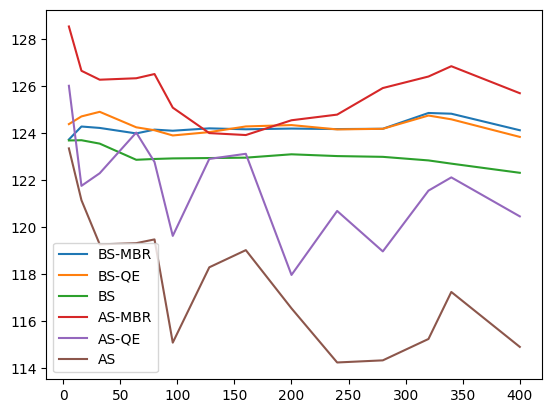

In [19]:
#标准差的折线图
plt.figure()
plt.plot(k_list,bs_std_len_mbr,label="BS-MBR")
plt.plot(k_list,bs_std_len_qe,label="BS-QE")
plt.plot(k_list,bs_std_len_bs,label="BS")
plt.plot(k_list,as_std_len_mbr,label="AS-MBR")
plt.plot(k_list,as_std_len_qe,label="AS-QE")
plt.plot(k_list,as_std_len_bs,label="AS")
plt.legend()
plt.show()

In [10]:
#提取评价指标
bs_mbr_metrics = {}
bs_qe_metrics = {}
bs_metrics = {}
bs_smbr_metrics = {}
for k in tqdm(k_list):
    with open(path_prefix+'_bs/output_{}/mbr_baseline/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_mbr_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'_bs/output_{}/qe_baseline/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_qe_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'_bs/output_{}/baseline/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_metrics[k] = [extract_scores(f.read())]
    with open(path_prefix+'_bs/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_smbr_metrics[k] = [extract_scores(f.read())]
    assert len(bs_mbr_metrics[k]) == len(bs_qe_metrics[k]) == len(bs_metrics[k])== len(bs_smbr_metrics[k])

100%|██████████| 14/14 [00:00<00:00, 28.42it/s]


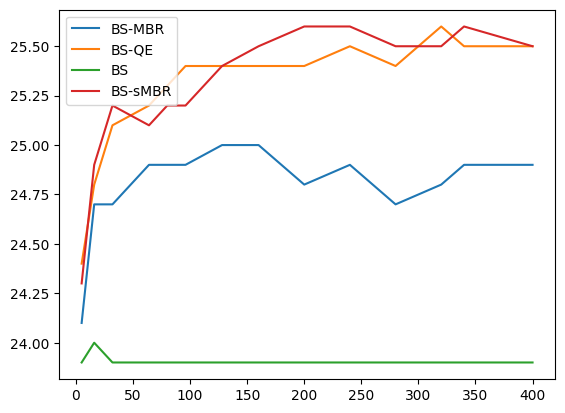

In [11]:
#BLEU
bs_mbr_bleu = []
bs_qe_bleu = []
bs_bleu = []
bs_smbr_bleu = []
for k in k_list:
    bs_mbr_bleu.append(bs_mbr_metrics[k][0]["BLEU"])
    bs_qe_bleu.append(bs_qe_metrics[k][0]["BLEU"])
    bs_bleu.append(bs_metrics[k][0]["BLEU"])
    bs_smbr_bleu.append(bs_smbr_metrics[k][0]["BLEU"])
plt.figure()
plt.plot(k_list,bs_mbr_bleu,label="BS-MBR")
plt.plot(k_list,bs_qe_bleu,label="BS-QE")
plt.plot(k_list,bs_bleu,label="BS")
plt.plot(k_list,bs_smbr_bleu,label="BS-sMBR")
plt.legend()
plt.show()


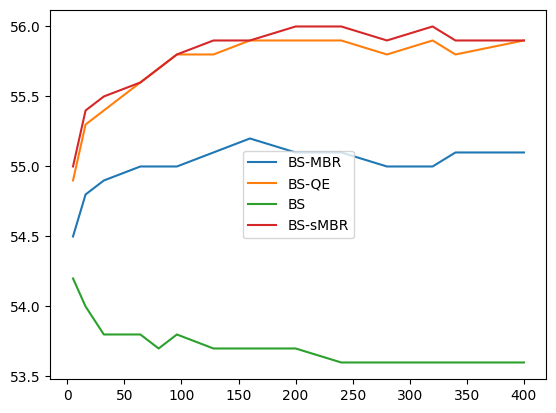

In [12]:
#chrF2
bs_mbr_chrf2 = []
bs_qe_chrf2 = []
bs_chrf2 = []
bs_smbr_chrf2 = []
for k in k_list:
    bs_mbr_chrf2.append(bs_mbr_metrics[k][0]["chrF2"])
    bs_qe_chrf2.append(bs_qe_metrics[k][0]["chrF2"])
    bs_chrf2.append(bs_metrics[k][0]["chrF2"])
    bs_smbr_chrf2.append(bs_smbr_metrics[k][0]["chrF2"])
plt.figure()
plt.plot(k_list,bs_mbr_chrf2,label="BS-MBR")
plt.plot(k_list,bs_qe_chrf2,label="BS-QE")
plt.plot(k_list,bs_chrf2,label="BS")
plt.plot(k_list,bs_smbr_chrf2,label="BS-sMBR")
plt.legend()
plt.show()

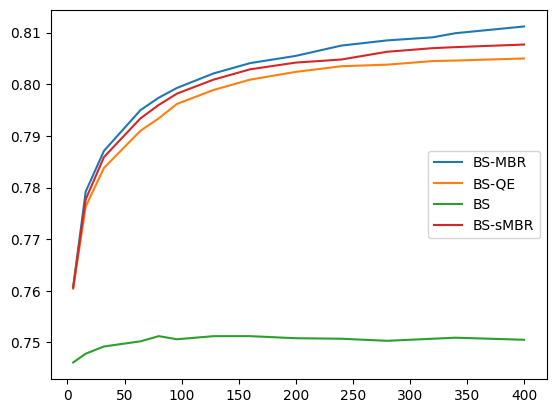

In [13]:
#comet
bs_mbr_comet = []
bs_qe_comet = []
bs_comet = []
bs_smbr_comet = []
for k in k_list:
    bs_mbr_comet.append(bs_mbr_metrics[k][0]["comet"])
    bs_qe_comet.append(bs_qe_metrics[k][0]["comet"])
    bs_comet.append(bs_metrics[k][0]["comet"])
    bs_smbr_comet.append(bs_smbr_metrics[k][0]["comet"])
plt.figure()
plt.plot(k_list,bs_mbr_comet,label="BS-MBR")
plt.plot(k_list,bs_qe_comet,label="BS-QE")
plt.plot(k_list,bs_comet,label="BS")
plt.plot(k_list,bs_smbr_comet,label="BS-sMBR")
plt.legend()
plt.show()

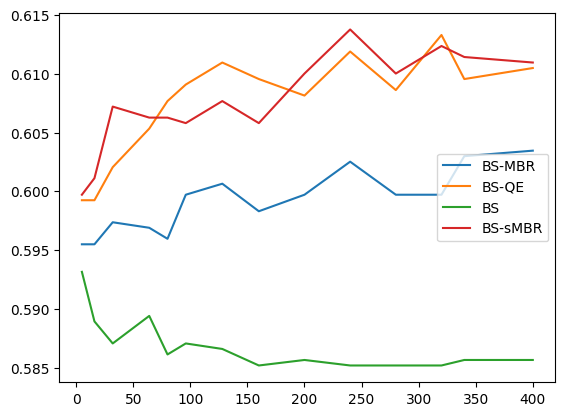

In [14]:
#entity accuracy
bs_mbr_entity_accuracy = []
bs_qe_entity_accuracy = []
bs_entity_accuracy = []
bs_smbr_entity_accuracy = []
for k in k_list:
    bs_mbr_entity_accuracy.append(bs_mbr_metrics[k][0]["entity Accuracy"])
    bs_qe_entity_accuracy.append(bs_qe_metrics[k][0]["entity Accuracy"])
    bs_entity_accuracy.append(bs_metrics[k][0]["entity Accuracy"])
    bs_smbr_entity_accuracy.append(bs_smbr_metrics[k][0]["entity Accuracy"])
plt.figure()
plt.plot(k_list,bs_mbr_entity_accuracy,label="BS-MBR")
plt.plot(k_list,bs_qe_entity_accuracy,label="BS-QE")
plt.plot(k_list,bs_entity_accuracy,label="BS")
plt.plot(k_list,bs_smbr_entity_accuracy,label="BS-sMBR")
plt.legend()
plt.show()

In [15]:
#num_acc
bs_mbr_num_acc = []
as_mbr_num_acc = []
bs_qe_num_acc = []
as_qe_num_acc = []
bs_num_acc = []
as_num_acc = []
for k in k_list:
    bs_mbr_num_acc.append(bs_mbr_metrics[k][0]["num_acc"])
    bs_qe_num_acc.append(bs_qe_metrics[k][0]["num_acc"])
    bs_num_acc.append(bs_metrics[k][0]["num_acc"])
    as_mbr_num_acc.append(as_mbr_metrics[k][0]["num_acc"])
    as_qe_num_acc.append(as_qe_metrics[k][0]["num_acc"])
    as_num_acc.append(as_metrics[k][0]["num_acc"])
plt.figure()
plt.plot(k_list,bs_mbr_num_acc,label="BS-MBR")
plt.plot(k_list,bs_qe_num_acc,label="BS-QE")
plt.plot(k_list,bs_num_acc,label="BS")
plt.plot(k_list,as_mbr_num_acc,label="AS-MBR")
plt.plot(k_list,as_qe_num_acc,label="AS-QE")
plt.plot(k_list,as_num_acc,label="AS")
plt.legend()
plt.show()

KeyError: 'num_acc'

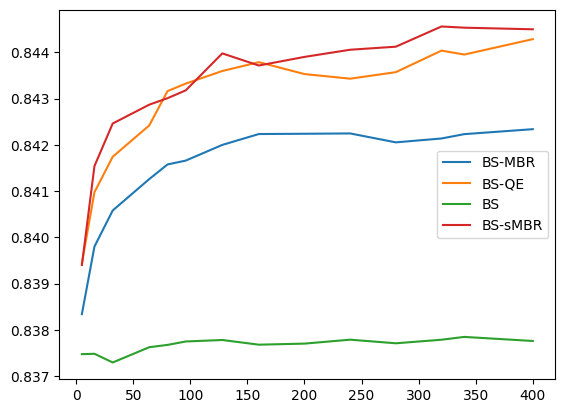

In [16]:
#bertscore F1
bs_mbr_bertscore_f1 = []
bs_qe_bertscore_f1 = []
bs_bertscore_f1 = []
bs_smbr_bertscore_f1 = []
for k in k_list:
    bs_mbr_bertscore_f1.append(bs_mbr_metrics[k][0]["bertscore F1"])
    bs_qe_bertscore_f1.append(bs_qe_metrics[k][0]["bertscore F1"])
    bs_bertscore_f1.append(bs_metrics[k][0]["bertscore F1"])
    bs_smbr_bertscore_f1.append(bs_smbr_metrics[k][0]["bertscore F1"])
plt.figure()
plt.plot(k_list,bs_mbr_bertscore_f1,label="BS-MBR")
plt.plot(k_list,bs_qe_bertscore_f1,label="BS-QE")
plt.plot(k_list,bs_bertscore_f1,label="BS")
plt.plot(k_list,bs_smbr_bertscore_f1,label="BS-sMBR")
plt.legend()
plt.show()

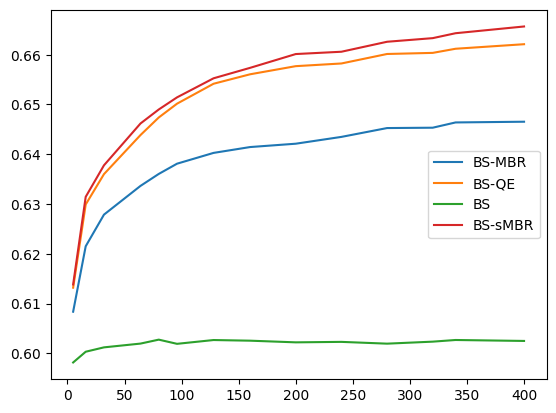

In [17]:
#BLEURT
bs_mbr_bleurt = []
bs_qe_bleurt = []
bs_bleurt = []
bs_smbr_bleurt = []
for k in k_list:
    bs_mbr_bleurt.append(bs_mbr_metrics[k][0]["BLEURT"])
    bs_qe_bleurt.append(bs_qe_metrics[k][0]["BLEURT"])
    bs_bleurt.append(bs_metrics[k][0]["BLEURT"])
    bs_smbr_bleurt.append(bs_smbr_metrics[k][0]["BLEURT"])
plt.figure()
plt.plot(k_list,bs_mbr_bleurt,label="BS-MBR")
plt.plot(k_list,bs_qe_bleurt,label="BS-QE")
plt.plot(k_list,bs_bleurt,label="BS")
plt.plot(k_list,bs_smbr_bleurt,label="BS-sMBR")
plt.legend()
plt.show()

In [20]:
#perplexity
mbr_perplexity = {}
qe_perplexity = {}
bs_perplexity = {}
for k in k_list:
    with open(path_prefix+'/mbr_bs/output_{}/mbr.output.perplexity'.format(k,k),"r",encoding="utf-8") as f:
        mbr_perplexity[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/qe_bs/output_{}/qe.output.perplexity'.format(k),"r",encoding="utf-8") as f:
        qe_perplexity[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/bs/{}/hypo_1.perplexity'.format(k),"r",encoding="utf-8") as f:
        bs_perplexity[k] = [float(line.strip()) for line in f.readlines()]
    assert len(mbr_perplexity[k]) == len(qe_perplexity[k]) == len(bs_perplexity[k])
mean_mbr=[]
mean_qe=[]
mean_bs=[]
std_mbr=[]
std_qe=[]
std_bs=[]
for k in k_list:
    mean_mbr.append(np.mean(mbr_perplexity[k]))
    mean_qe.append(np.mean(qe_perplexity[k]))
    mean_bs.append(np.mean(bs_perplexity[k]))
    std_mbr.append(np.std(mbr_perplexity[k]))
    std_qe.append(np.std(qe_perplexity[k]))
    std_bs.append(np.std(bs_perplexity[k]))

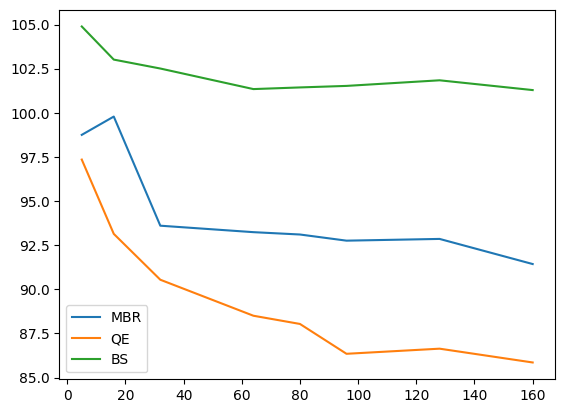

In [5]:
plt.figure()
plt.plot(k_list,mean_mbr,label="MBR")
plt.plot(k_list,mean_qe,label="QE")
plt.plot(k_list,mean_bs,label="BS")
plt.legend()
plt.show()